In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
path="/content/1_boston_housing (1).csv"
df = pd.read_csv(path)

# Remove quotes from column names (important for your dataset)
df.columns = df.columns.str.replace('"', '')

# Display first 5 rows
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [5]:
X = df.drop("MEDV", axis=1)   # Features
y = df["MEDV"]                # Target

print(X.shape, y.shape)


(506, 13) (506,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
model = Sequential()
model.add(Dense(1, input_shape=(X_train.shape[1],), activation='linear'))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.05,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 604.2187 - mae: 22.8478 - val_loss: 532.7211 - val_mae: 21.7259
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 602.7684 - mae: 22.8368 - val_loss: 532.6644 - val_mae: 21.7292
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 601.2739 - mae: 22.8229 - val_loss: 532.5753 - val_mae: 21.7313
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 600.0113 - mae: 22.8151 - val_loss: 532.5273 - val_mae: 21.7348
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 598.4313 - mae: 22.7977 - val_loss: 532.3677 - val_mae: 21.7342
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 597.1107 - mae: 22.7840 - val_loss: 532.2511 - val_mae: 21.7352
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 595.8169 - mae: 22.7733 - val_loss: 532.1571 - val_mae: 21.7365
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 594.4661 - mae: 22.7610 - val_loss: 532.0805 - val_mae: 21.7380
Epoch 9/

In [9]:
#Step 6: Build Deep Neural Network
model = Sequential()

# Single neuron → behaves like linear regression
model.add(Dense(1, input_shape=(X_train.shape[1],), activation='linear'))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │            14 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (56.00 B)

 Trainable params: 14 (56.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
#Step 7: Train Model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 628.0682 - mae: 22.9430 - val_loss: 568.0349 - val_mae: 22.1656
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 625.4206 - mae: 22.9189 - val_loss: 566.2634 - val_mae: 22.1499
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 622.9954 - mae: 22.8996 - val_loss: 564.5286 - val_mae: 22.1341
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 620.5008 - mae: 22.8745 - val_loss: 562.8516 - val_mae: 22.1181
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 618.1815 - mae: 22.8561 - val_loss: 561.1008 - val_mae: 22.1023
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 615.7004 - mae: 22.8289 - val_loss: 559.5490 - val_mae: 22.0857
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 613.5597 - mae: 22.8057 - val_loss: 558.0850 - val_mae: 22.0687
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 611.4716 - mae: 22.7867 - val_loss: 556.4935 - val_mae: 22.0526
Epoch 9/100
21/

In [11]:
#Step 8: Evaluate Model
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 445.3542 - mae: 20.2143 
Test Loss (MSE): 445.3541564941406
Test MAE: 20.21430206298828


In [12]:
y_pred = model.predict(X_test)

# Compare actual vs predicted
for i in range(5):
    print(f"Actual: {y_test.iloc[i]:.2f} | Predicted: {y_pred[i][0]:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Actual: 23.60 | Predicted: 4.13
Actual: 32.40 | Predicted: 8.66
Actual: 13.60 | Predicted: -2.94
Actual: 22.80 | Predicted: 4.79
Actual: 16.10 | Predicted: -3.44


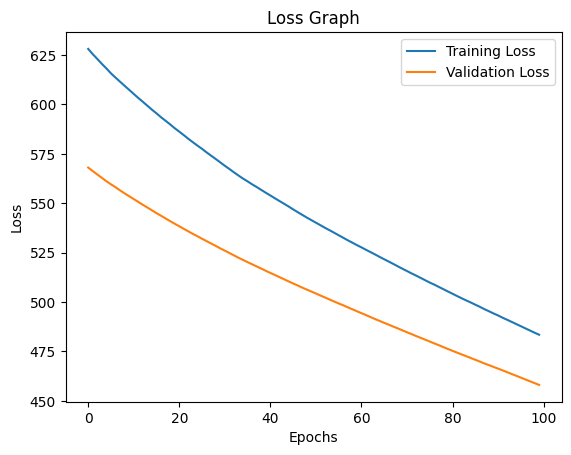

In [13]:
#Step 10: Plot Training Graphs
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()